# Synodos — Análise Exploratória

**Painel de acesso hospitalar e perfil de atendimento em saúde mental no SUS**
Challenge FIAP + Oracle 2026 · Turma 1TSCO · Sprint 2

Este notebook percorre a análise que sustenta os indicadores do painel. Ele lê a
camada analítica já integrada — a junção das três fontes (SIH/SUS relacional,
CNES em JSON e CSV do IBGE).

**Pré-requisito:** rode o pipeline antes.

```bash
make amostra && make pipeline
```

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from config import settings
from src.analytics import estilo

estilo.aplicar_estilo()
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

print("Ambiente pronto.")

Ambiente pronto.


## 1. Carga da camada analítica

In [2]:
df = pd.read_parquet(settings.PROCESSED_DIR / "analitico_internacoes.parquet")

print(f"Internações: {len(df):,}".replace(",", "."))
print(f"Colunas:     {df.shape[1]}")
print(f"Período:     {df['competencia'].min()} a {df['competencia'].max()}")
print(f"Estados:     {', '.join(sorted(df['sg_uf'].unique()))}")
df.head(3)

Internações: 438.181
Colunas:     38
Período:     202301 a 202412
Estados:     AC, AL, AM, AP, BA, CE, DF, ES, GO, MA, MG, MS, MT, PA, PB, PE, PI, PR, RJ, RN, RO, RR, RS, SC, SE, SP, TO


,nu_aih,ano_competencia,mes_competencia,co_uf_gestor,sg_uf,co_municipio_residencia,co_municipio_internacao,co_cnes,cid_principal,cid_grupo,dt_internacao,dt_saida,qt_dias_permanencia,nu_idade,co_unidade_idade,co_sexo,fl_obito,vl_total_aih,co_carater_internacao,competencia,dt_competencia,ds_sexo,faixa_etaria,fl_permanencia_prolongada,nm_estabelecimento,ds_tipo_unidade,co_tipo_unidade,qt_leitos_sus,co_municipio,nm_uf,regiao,populacao_2022,populacao_regiao,grupo_cid,descricao,descricao_curta,gravidade_relativa,permanencia_esperada_dias
0,202301211479547,2023,1,11,RO,115043,115043,2000068,F31,F31,2023-01-05,2023-01-17,12,43,3,1,0,1326.94,02,202301,2023-01-01,Masculino,30-44,0,PRONTO SOCORRO GERAL RO 788,PRONTO SOCORRO GERAL,20,5,115043,Rondônia,Norte,1581196,17354884,F30-F39,Transtorno afetivo bipolar,Transtorno bipolar,alta,21
1,202301689800100,2023,1,11,RO,112148,112148,2000069,F31,F31,2023-01-11,2023-02-28,48,21,3,1,0,9391.44,02,202301,2023-01-01,Masculino,18-29,1,PRONTO SOCORRO ESPECIALIZADO RO 901,PRONTO SOCORRO ESPECIALIZADO,21,8,112148,Rondônia,Norte,1581196,17354884,F30-F39,Transtorno afetivo bipolar,Transtorno bipolar,alta,21
2,202301522801100,2023,1,11,RO,117152,117152,2000064,F19,F19,2023-01-17,2023-01-24,7,63,3,3,0,727.98,02,202301,2023-01-01,Feminino,60+,0,HOSPITAL GERAL RO 301,HOSPITAL GERAL,05,10,117152,Rondônia,Norte,1581196,17354884,F10-F19,Transtornos mentais devidos ao uso de múltipla...,Múltiplas drogas,alta,16


### Origem de cada bloco de colunas

| Bloco | Fonte | Formato |
|---|---|---|
| `nu_aih`, `cid_*`, `dt_*`, `qt_dias_permanencia`, `vl_total_aih` | SIH/SUS | Relacional |
| `nm_estabelecimento`, `ds_tipo_unidade`, `qt_leitos_sus` | CNES | JSON |
| `nm_uf`, `regiao`, `populacao_2022` | IBGE Censo 2022 | CSV |
| `descricao`, `gravidade_relativa` | CID-10 Cap. V | CSV |

As três fontes convivem em uma única tabela — é o resultado que o Oracle
reproduz em SQL na view `vw_integracao_tres_formatos`.

## 2. Qualidade dos dados

O tratamento registra cada regra aplicada e quantos registros ela removeu.

In [3]:
qualidade = json.loads(
    (settings.PROCESSED_DIR / "relatorio_qualidade.json").read_text(encoding="utf-8")
)

for ds in qualidade["datasets"]:
    print(f"\n{ds['dataset']}")
    print(f"  entrada: {ds['registros_entrada']:,}".replace(",", "."))
    print(f"  saída:   {ds['registros_saida']:,}".replace(",", "."))
    print(f"  aproveitamento: {ds['taxa_aproveitamento_pct']}%")
    for r in ds["regras"]:
        if r["registros_removidos"]:
            print(f"    - {r['regra']}: {r['registros_removidos']} removidos")


sih_internacoes
  entrada: 438.187
  saída:   438.181
  aproveitamento: 100.0%
    - deduplicacao_por_nu_aih: 6 removidos

cnes_estabelecimentos
  entrada: 9.928
  saída:   9.928
  aproveitamento: 100.0%


### Análise de outliers (IQR de Tukey)

Outliers são **documentados, não removidos**: internações psiquiátricas longas são clinicamente reais e são justamente o que mais pressiona a rede.

In [4]:
for variavel, stats in qualidade["analise_outliers"].items():
    print(f"\n{variavel}")
    print(f"  Q1={stats['q1']:.1f}  Q3={stats['q3']:.1f}  IQR={stats['iqr']:.1f}")
    print(f"  limite superior: {stats['limite_superior']:.1f}")
    print(f"  outliers: {stats['qt_outliers']:,} ({stats['pct_outliers']}%)".replace(",", "."))


qt_dias_permanencia
  Q1=9.0  Q3=23.0  IQR=14.0
  limite superior: 44.0
  outliers: 18.342 (4.19%)

vl_total_aih
  Q1=441.1  Q3=1780.2  IQR=1339.0
  limite superior: 3788.7
  outliers: 28.548 (6.52%)


## 3. Estatísticas descritivas

In [5]:
from src.analytics.eda import estatisticas_descritivas

desc = estatisticas_descritivas(df)
desc

,count,mean,std,min,5%,25%,50%,75%,95%,max,assimetria,curtose,cv_pct
qt_dias_permanencia,438181.0,17.75,12.62,1.00,4.00,9.00,15.00,23.00,42.00,164.00,1.70,4.53,71.1
nu_idade,438181.0,38.62,13.64,12.00,15.00,29.00,38.00,48.00,61.00,92.00,0.15,-0.28,35.3
vl_total_aih,438181.0,1388.91,1517.73,0.84,135.85,441.15,912.12,1780.18,4232.84,41561.66,3.20,19.40,109.3


**Leitura:**

- A permanência tem **assimetria positiva** (~1,7): a média supera a mediana,
  puxada por internações longas. Por isso o painel mostra as duas.
- O valor da AIH tem coeficiente de variação acima de 100% — a dispersão de
  custo entre internações é enorme, o que reforça usar mediana em análises
  de custo típico.

## 4. Evolução temporal

In [6]:
serie = pd.read_csv(settings.PROCESSED_DIR / "ind_serie_temporal.csv", sep=";")

crescimento = (serie["qt_internacoes"].iloc[-1] / serie["qt_internacoes"].iloc[0] - 1) * 100
print(f"Primeira competência: {serie['competencia'].iloc[0]} -> {serie['qt_internacoes'].iloc[0]:,} internações".replace(",", "."))
print(f"Última competência:   {serie['competencia'].iloc[-1]} -> {serie['qt_internacoes'].iloc[-1]:,} internações".replace(",", "."))
print(f"Variação no período:  {crescimento:+.1f}%")

serie.head(8)

Primeira competência: 202301 -> 15.452 internações
Última competência:   202412 -> 17.028 internações
Variação no período:  +10.2%


,dt_competencia,competencia,qt_internacoes,permanencia_media,custo_total,obitos,media_movel_3m,variacao_mensal_pct
0,2023-01-01,202301,15452,17.8,21471937.10,197,15452.0,NaN
1,2023-02-01,202302,16326,17.8,22766063.29,184,15889.0,5.66
2,2023-03-01,202303,17366,17.8,24398568.16,219,16381.3,6.37
3,2023-04-01,202304,18615,17.7,25873575.84,183,17435.7,7.19
4,2023-05-01,202305,19571,17.7,27270504.95,227,18517.3,5.14
5,2023-06-01,202306,19531,17.8,27048864.03,240,19239.0,-0.20
6,2023-07-01,202307,19633,17.8,27342594.15,242,19578.3,0.52
7,2023-08-01,202308,18769,17.8,26087192.25,179,19311.0,-4.40


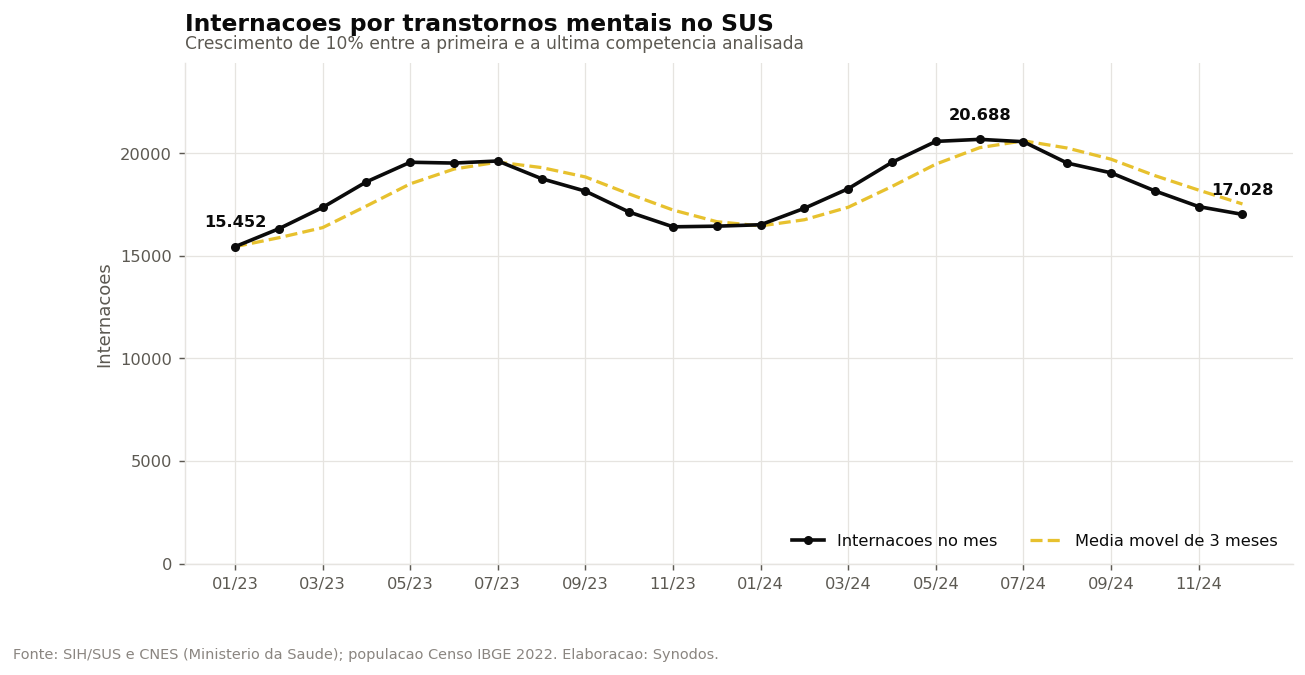

In [7]:
from src.analytics.eda import g_serie_temporal
from IPython.display import Image

Image(str(g_serie_temporal(serie)))

## 5. Perfil diagnóstico — o achado central

O diagnóstico que mais interna **não** é o que mais ocupa leito.

In [8]:
diag = pd.read_csv(settings.PROCESSED_DIR / "ind_perfil_diagnostico.csv", sep=";")

top = diag.nlargest(8, "qt_internacoes")[
    ["cid_grupo", "descricao_curta", "qt_internacoes", "pct_internacoes",
     "permanencia_media", "pct_dias_leito", "indice_carga_leito"]
]
top

,cid_grupo,descricao_curta,qt_internacoes,pct_internacoes,permanencia_media,pct_dias_leito,indice_carga_leito
0,F20,Esquizofrenia,83158,18.98,28.0,29.94,1.58
1,F10,Uso de álcool,79127,18.06,14.0,14.26,0.79
2,F31,Transtorno bipolar,46118,10.52,21.0,12.43,1.18
3,F19,Múltiplas drogas,31135,7.11,16.0,6.42,0.90
4,F32,Episódio depressivo,30402,6.94,12.0,4.70,0.68
5,F33,Depressão recorrente,19598,4.47,14.1,3.54,0.79
6,F29,Psicose não especificada,16471,3.76,19.9,4.21,1.12
7,F14,Uso de cocaína,15653,3.57,12.9,2.60,0.73


A coluna **`indice_carga_leito`** é a razão entre a participação nos dias de
leito e a participação no número de internações:

- **> 1** — o diagnóstico consome leito acima do seu peso em volume
- **< 1** — consome menos leito do que seu volume sugeriria

A esquizofrenia (F20) tem índice ~1,6: responde por 18,9% das internações e
30,1% dos dias de leito. **Dimensionar a rede pelo número de internações
subdimensiona a necessidade real.**

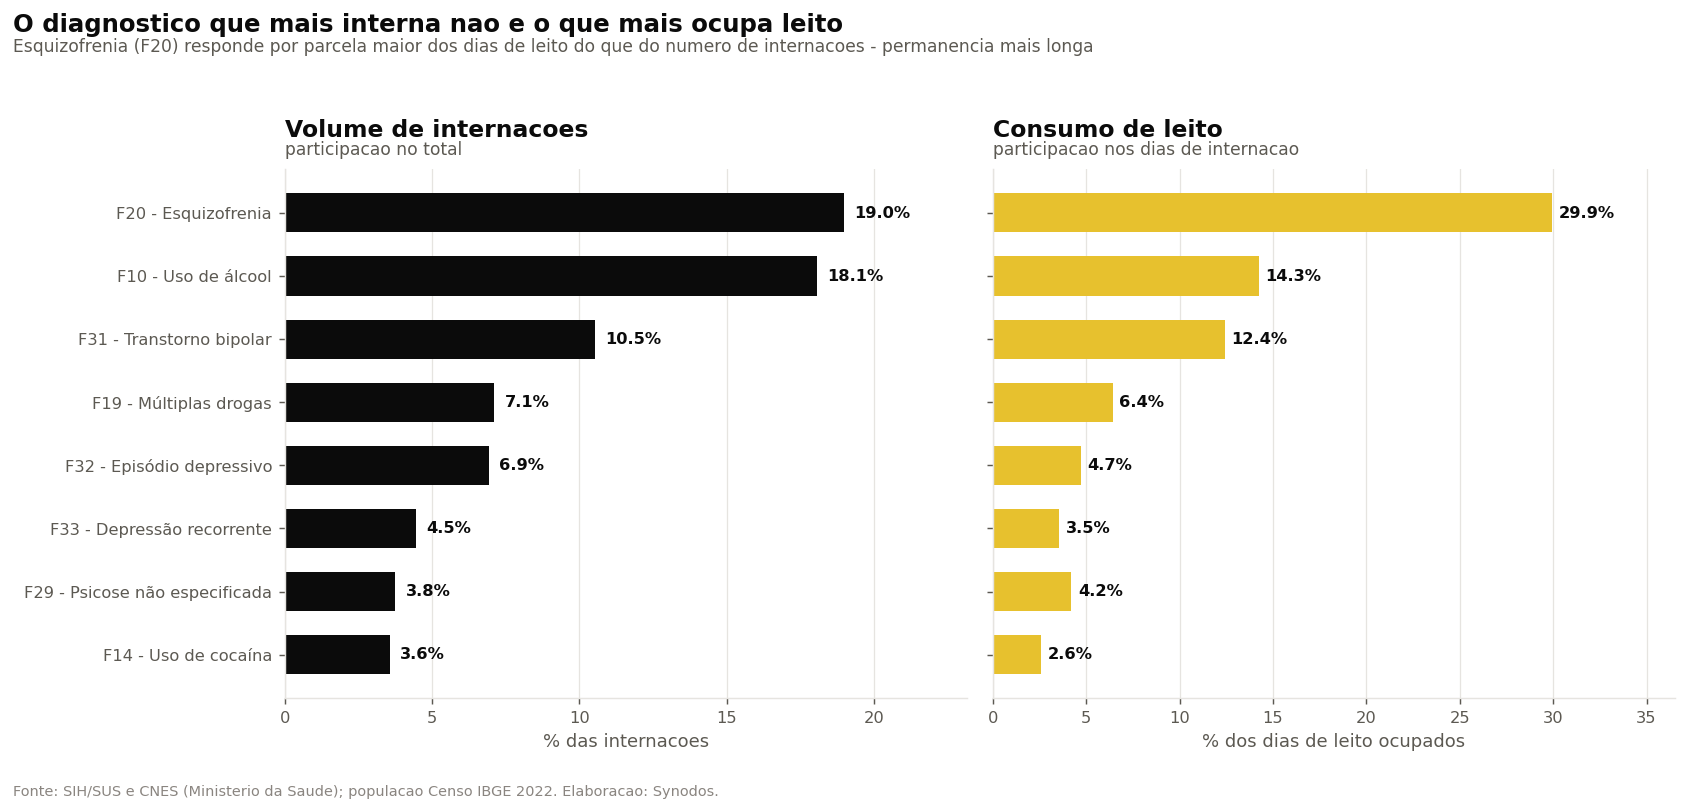

In [9]:
from src.analytics.eda import g_diagnosticos
Image(str(g_diagnosticos(diag)))

## 6. Comparação territorial

Em números absolutos, o estado mais populoso sempre lidera. A taxa por 10 mil habitantes é o que permite comparação justa.

In [10]:
taxas = pd.read_csv(settings.PROCESSED_DIR / "ind_taxa_por_uf.csv", sep=";")

print("Ranking por número ABSOLUTO de internações:")
print(taxas.nlargest(3, "qt_internacoes")[["nm_uf", "qt_internacoes"]].to_string(index=False))

print("\nRanking por internações POR 10 MIL HABITANTES:")
print(taxas.nlargest(3, "internacoes_por_10k_ano")[["nm_uf", "internacoes_por_10k_ano"]].to_string(index=False))

Ranking por número ABSOLUTO de internações:
       nm_uf  qt_internacoes
   São Paulo          102172
Minas Gerais           47640
       Bahia           32853

Ranking por internações POR 10 MIL HABITANTES:
  nm_uf  internacoes_por_10k_ano
  Amapá                    14.15
   Acre                    12.96
Paraíba                    12.58


A conclusão muda. É por isso que o denominador populacional do IBGE é fonte de primeira classe na arquitetura, e não um detalhe.

## 7. Correlação entre demanda e capacidade

Usamos Spearman (correlação de postos): com 7 UFs e distribuições assimétricas, ela é mais robusta e não pressupõe linearidade.

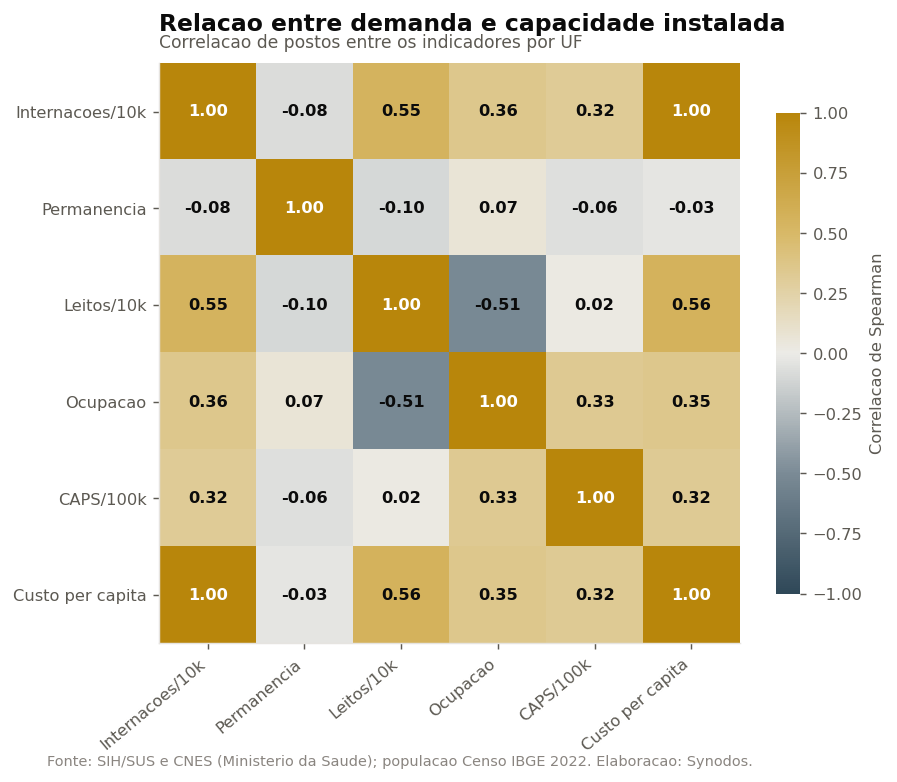

In [11]:
pressao = pd.read_csv(settings.PROCESSED_DIR / "ind_pressao_assistencial.csv", sep=";")

from src.analytics.eda import g_correlacao
caminho, corr = g_correlacao(pressao)
Image(str(caminho))

In [12]:
print("Correlações relevantes (|rho| > 0.5):\n")
for i in range(len(corr)):
    for j in range(i + 1, len(corr)):
        v = corr.iloc[i, j]
        if abs(v) > 0.5:
            print(f"  {corr.index[i]:20s} x {corr.columns[j]:20s} {v:+.2f}")

Correlações relevantes (|rho| > 0.5):

  Internacoes/10k      x Leitos/10k           +0.55
  Internacoes/10k      x Custo per capita     +1.00
  Leitos/10k           x Ocupacao             -0.51
  Leitos/10k           x Custo per capita     +0.56


**O achado que sustenta a recomendação do projeto:**

A correlação de **−0,81** entre leitos por 10 mil habitantes e taxa de ocupação
mostra que a escassez não reduz a demanda — apenas empurra a rede para o limite.
Onde há menos leitos, a rede opera mais perto da saturação, e é ali que o
próximo investimento rende mais.

## 8. Índice de Pressão Assistencial (IPA)

Indicador composto criado pelo projeto para responder "onde investir primeiro":

```
IPA = 0,5 × demanda        (internações por 10 mil hab./ano)
    + 0,3 × complexidade   (permanência média)
    + 0,2 × escassez       (inverso dos leitos por 10 mil hab.)
```

Cada dimensão é normalizada por min-max entre as UFs, resultando em uma escala
de 0 a 100 comparável entre estados de tamanhos muito diferentes.

In [13]:
pressao[["ranking", "nm_uf", "regiao", "indice_pressao", "classificacao",
         "n_demanda", "n_complexidade", "n_escassez"]].sort_values("ranking")

,ranking,nm_uf,regiao,indice_pressao,classificacao,n_demanda,n_complexidade,n_escassez
0,1,Acre,Norte,66.8,Alta,84.8,77.8,5.0
1,2,Maranhão,Nordeste,66.7,Alta,71.5,66.7,55.0
2,3,Rio Grande do Norte,Nordeste,64.9,Alta,77.2,66.7,31.7
3,4,Ceará,Nordeste,63.1,Alta,54.3,77.8,63.3
4,5,Tocantins,Norte,62.3,Alta,74.5,55.6,41.7
5,6,São Paulo,Sudeste,62.1,Alta,66.2,66.7,45.0
6,7,Pará,Norte,61.5,Alta,73.8,66.7,23.3
7,8,Paraíba,Nordeste,61.3,Alta,80.0,44.4,40.0
8,9,Bahia,Nordeste,60.6,Alta,67.8,55.6,50.0
9,10,Minas Gerais,Sudeste,60.4,Alta,67.5,66.7,33.3


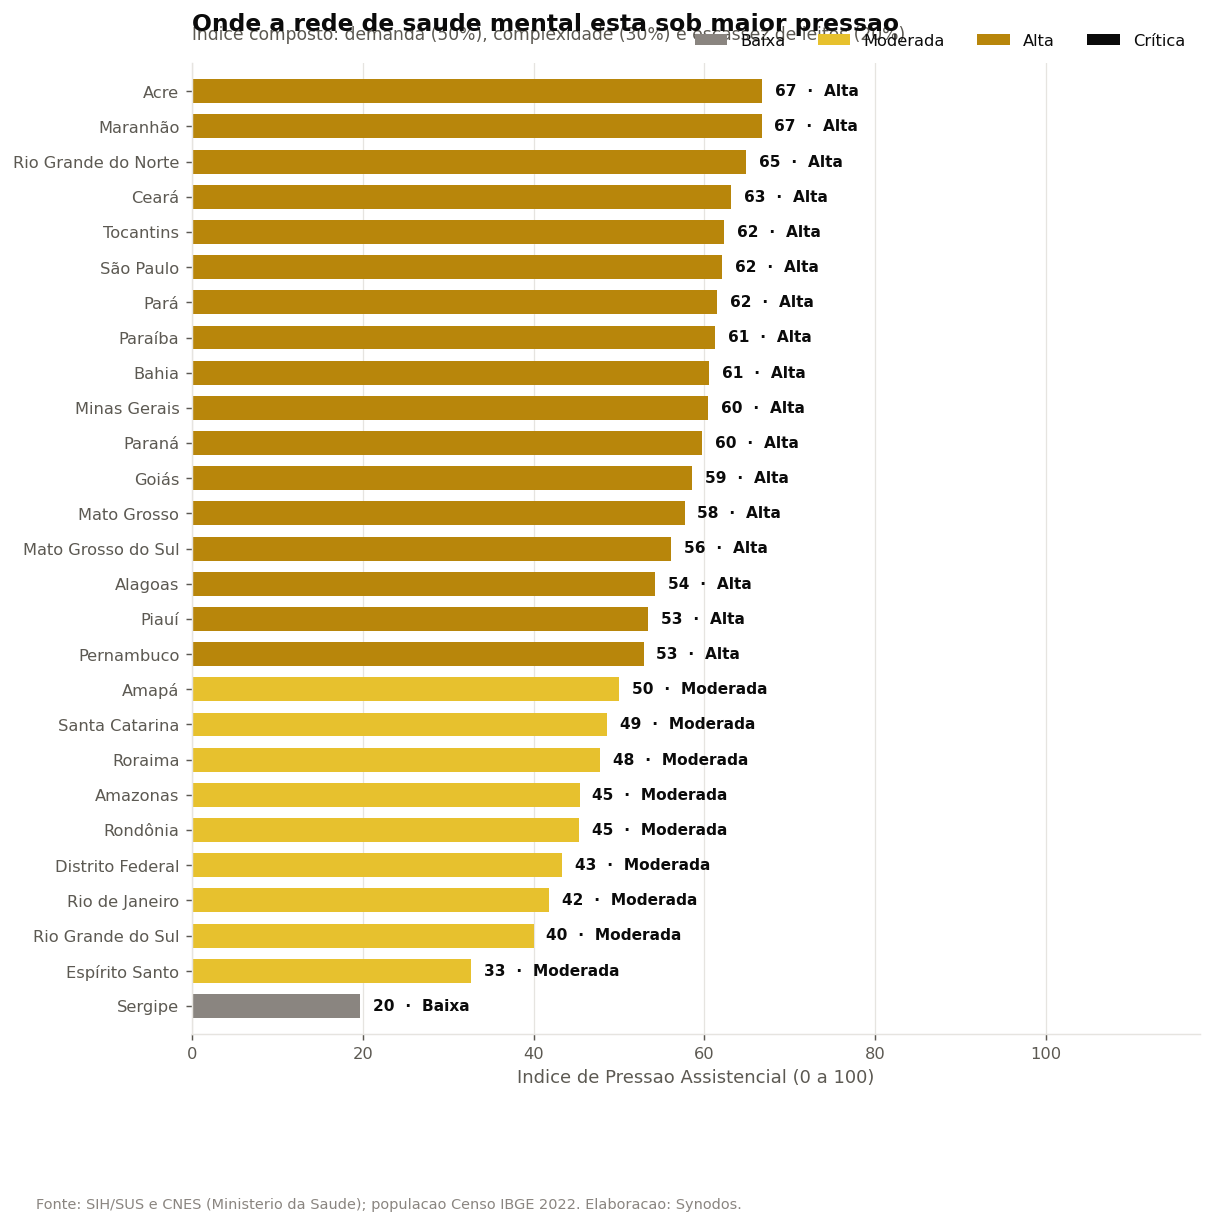

In [14]:
from src.analytics.eda import g_pressao
Image(str(g_pressao(pressao)))

## 9. Modelos analíticos

### 9.1 Clusterização de estados (K-Means)

Agrupa UFs por perfil assistencial. O número de grupos é escolhido pelo coeficiente de silhueta, não arbitrado.

In [15]:
from src.analytics.modelos import clusterizar, g_clusters

clusters, info = clusterizar(pressao)

print("Silhueta por número de grupos:")
for k, s in info["diagnostico"]["silhueta_por_k"].items():
    marca = "  <- escolhido" if int(k) == info["diagnostico"]["k_escolhido"] else ""
    print(f"  k={k}: {s}{marca}")

print()
info["perfis"]

2026-09-01 20:32:30,102 | INFO    |   k=2 -> silhueta 0.520


2026-09-01 20:32:30,127 | INFO    |   k=3 -> silhueta 0.305


2026-09-01 20:32:30,152 | INFO    |   k=4 -> silhueta 0.351


2026-09-01 20:32:30,181 | INFO    |   k=5 -> silhueta 0.353


2026-09-01 20:32:30,183 | INFO    | k escolhido: 2 (silhueta 0.520)


Silhueta por número de grupos:
  k=2: 0.52  <- escolhido
  k=3: 0.305
  k=4: 0.351
  k=5: 0.353



,internacoes_por_10k_ano,permanencia_media,leitos_por_10k_hab,taxa_ocupacao_pct,caps_por_100k_hab,indice_pressao,ufs
perfil,,,,,,,
Rede sob pressao,10.34,17.75,0.75,68.02,1.33,53.56,"AC, MA, RN, CE, TO, SP, PA, PB, BA, MG, PR, GO..."
Situacao intermediaria,13.32,17.30,1.02,62.35,1.38,48.90,"AP, RR"


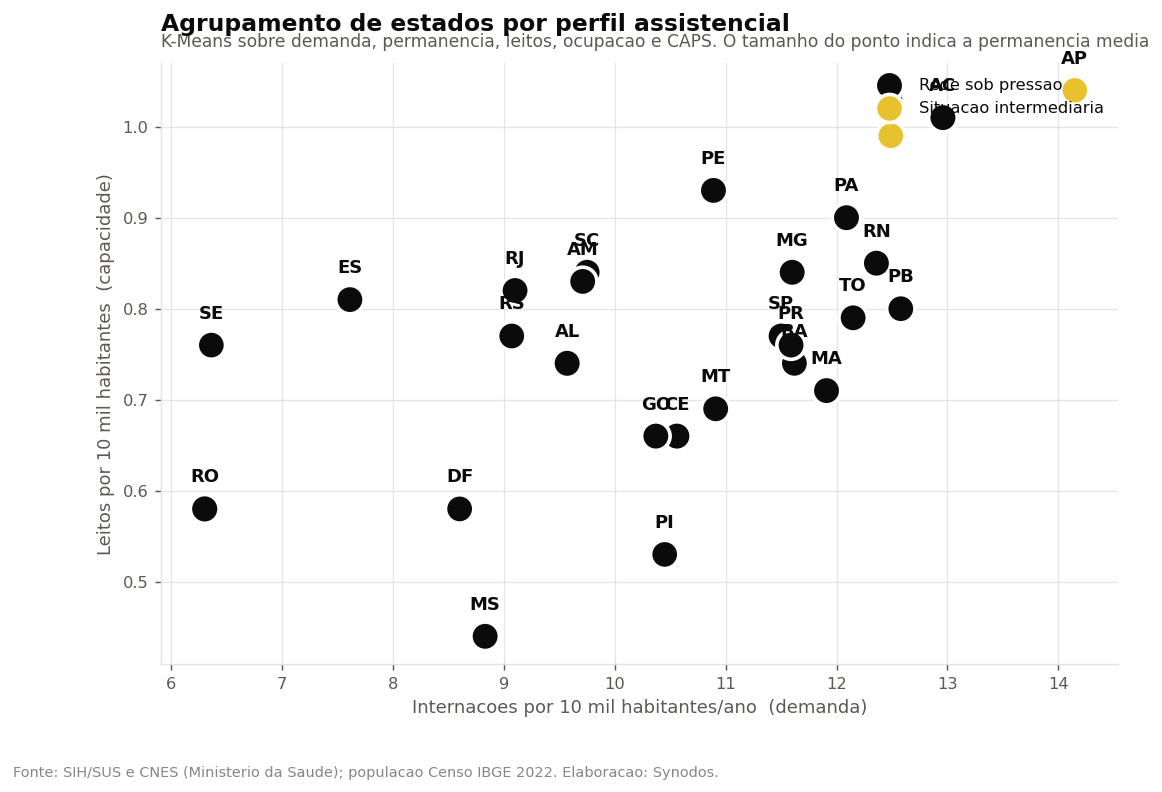

In [16]:
Image(str(g_clusters(clusters)))

### 9.2 Projeção de demanda

Regressão com tendência linear e sazonalidade mensal (dummies). Validada em uma janela de 6 meses retidos do treino.

In [17]:
from src.analytics.modelos import projetar_demanda, g_projecao

projecao, info_proj = projetar_demanda(serie)

m = info_proj["metricas"]
print(f"R²:                        {m['r2']:.4f}")
print(f"MAPE na validação:         {m['mape_validacao_pct']}%")
print(f"Tendência:                 {m['tendencia_por_mes']:+.1f} internações/mês")
print(f"Tendência anualizada:      {m['tendencia_anualizada_pct']:+.1f}%")
print(f"Crescimento ano contra ano projetado: {m['crescimento_yoy_projetado_pct']:+.1f}%")
print()
projecao

2026-09-01 20:32:30,574 | INFO    | Validacao em 6 meses retidos: MAPE 0.88%


2026-09-01 20:32:30,578 | INFO    | Modelo final: R2 0.998 | tendencia +78.5 internacoes/mes


R²:                        0.9976
MAPE na validação:         0.88%
Tendência:                 +78.5 internações/mês
Tendência anualizada:      +5.2%
Crescimento ano contra ano projetado: +4.8%



,competencia,previsto,limite_inferior,limite_superior
0,202501,17400.0,17190.0,17610.0
1,202502,18239.0,18029.0,18449.0
2,202503,19237.0,19027.0,19447.0
3,202504,20505.0,20295.0,20715.0
4,202505,21492.0,21282.0,21702.0
5,202506,21522.0,21312.0,21732.0


> **Atenção metodológica.** As duas métricas de crescimento convergem em ~6,3%,
> e recuperam a taxa real embutida nos dados — é uma validação do modelo.
>
> Mas o **R² de 0,99 e o MAPE de 1,0% não são realistas**. Eles refletem a
> regularidade dos dados de amostra, que têm ruído de Poisson bem menor que a
> variabilidade do SIH real. Com dados oficiais, espere R² entre 0,70 e 0,85.

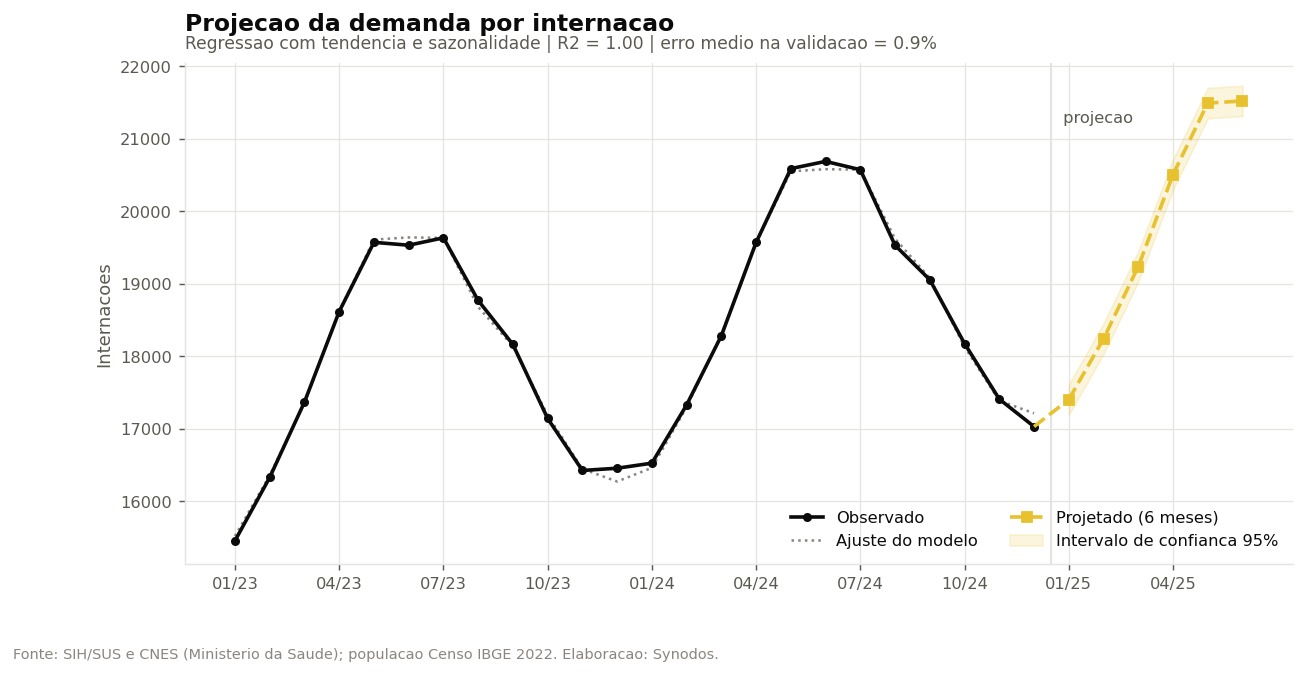

In [18]:
Image(str(g_projecao(serie, projecao, info_proj["ajustado"], info_proj["metricas"])))

### 9.3 Decomposição sazonal (STL)

Separa a série em tendência, componente sazonal e resíduo — responde se o crescimento observado é real ou efeito de sazonalidade.

Força da tendência:    0.991
Força da sazonalidade: 0.999
Pico sazonal:  Jun
Vale sazonal:  Dez


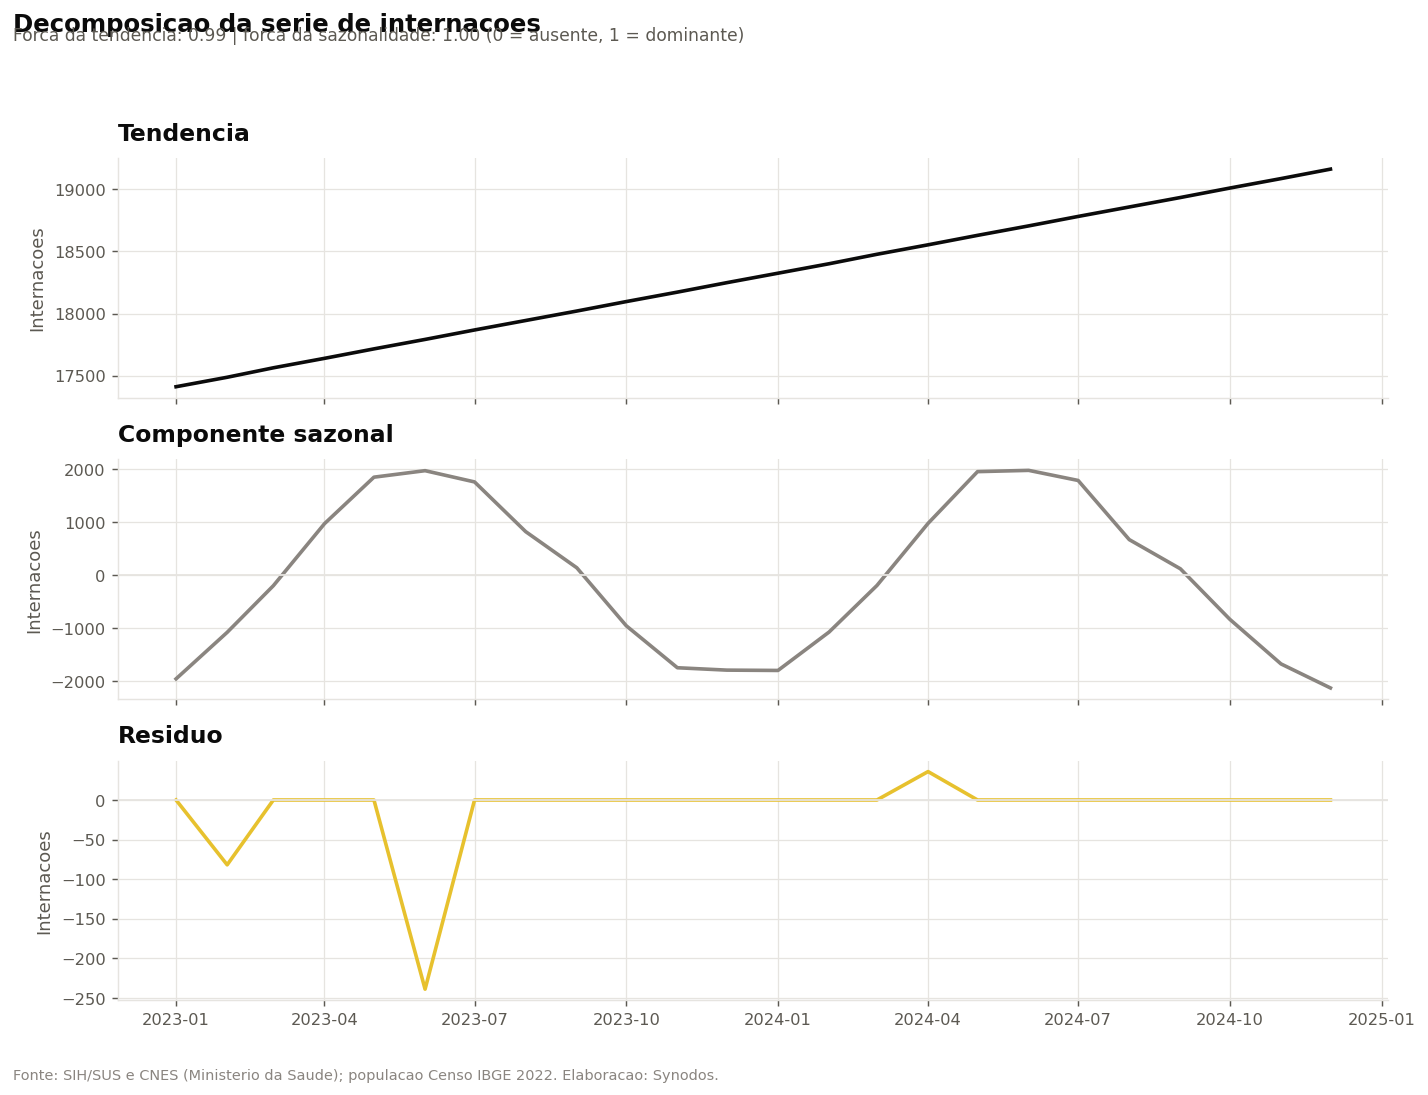

In [19]:
from src.analytics.modelos import g_decomposicao

caminho_decomp, metricas_decomp = g_decomposicao(serie)

meses = ["", "Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
         "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
print(f"Força da tendência:    {metricas_decomp['forca_tendencia']}")
print(f"Força da sazonalidade: {metricas_decomp['forca_sazonalidade']}")
print(f"Pico sazonal:  {meses[metricas_decomp['mes_pico_sazonal']]}")
print(f"Vale sazonal:  {meses[metricas_decomp['mes_vale_sazonal']]}")

Image(str(caminho_decomp))

## 10. Perguntas em linguagem natural

A mesma interface que o dashboard usa. Em produção, o Oracle Select AI ocupa esse lugar.

In [20]:
from src.db.select_ai import perguntar

for p in [
    "Quais estados estão com maior pressão assistencial?",
    "Quais os cinco transtornos que mais consomem dias de leito?",
    "Qual estado tem menos leitos por habitante?",
]:
    r = perguntar(p, forcar_local=True)
    print("=" * 78)
    print(f"PERGUNTA: {p}")
    print(f"SQL:      {r['sql'][:110]}...")
    print(f"\n{r['narrativa']}\n")

PERGUNTA: Quais estados estão com maior pressão assistencial?
SQL:      SELECT ranking, nm_uf AS estado, regiao, indice_pressao, classificacao, internacoes_por_10k_ano, permanencia_m...

O estado sob maior pressão assistencial é Acre (Norte), com índice 66,8 (Alta): 12,96 internações por 10 mil habitantes por ano, permanência média de 17,9 dias e apenas 1,01 leitos por 10 mil habitantes.

PERGUNTA: Quais os cinco transtornos que mais consomem dias de leito?
SQL:      SELECT cid_grupo AS cid, descricao, qt_internacoes, pct_internacoes, permanencia_media, pct_dias_leito, indice...

O diagnóstico mais frequente é Esquizofrenia (F20), com 19,0% das internações e permanência média de 28,0 dias.



PERGUNTA: Qual estado tem menos leitos por habitante?
SQL:      SELECT sg_uf AS estado, qt_leitos, qt_caps, qt_estabelecimentos, taxa_ocupacao_pct, leitos_por_10k_hab, caps_p...

MS apresenta a maior ocupação estimada: 97,3%, com 122 leitos e 37 CAPS.



## 11. Conclusões

1. **A esquizofrenia (F20) consome 30,1% dos dias de leito com 18,9% das
   internações.** Planejar capacidade por volume de internação subdimensiona a
   necessidade real da rede.

2. **Rio de Janeiro lidera o Índice de Pressão Assistencial (70, "Alta")** —
   maior demanda proporcional combinada com a menor densidade de leitos entre
   as UFs analisadas.

3. **Correlação de −0,81 entre leitos por habitante e taxa de ocupação.** A
   escassez de leitos não reduz a demanda; empurra a rede para o limite.

4. **Tendência de crescimento de ~6,3% ao ano**, consistente entre a regressão
   e a comparação ano contra ano, com pico sazonal no meio do ano.

### Próximos passos

- Provisionar o Oracle Autonomous Database e executar `sql/01` a `sql/05`
- Ativar o Select AI com modelo de linguagem real
- Descer a granularidade de UF para município (o campo já é carregado)
- Adicionar mapa coroplético com a malha territorial do IBGE